<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX Week 4 Day 1: Train / Validation / Test Splits
</h1>


<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 1 Learning Objectives:</b>
-  <b>The Three-Way Split:</b> Partition data into Training (60%), Validation (20%), and Test (20%) sets.
-  <b>Prevent Test Leakage:</b> Understand why tuning against a test set creates optimistic, untrustworthy performance estimates.
-  <b>Hyperparameter Tuning:</b> Tune the $k$-NN classifier's hyperparameter ($k$) strictly using the validation set.
-  <b>Final Evaluation:</b> Unlock and evaluate the test set exactly once at the end of the pipeline.

</blockquote>


## <span style="color: #39b64eff">1.1 Environment Setup & Library Imports</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import core data manipulation libraries alongside Scikit-Learn tools for dataset splitting, feature scaling, $k$-Nearest Neighbors classification, and multi-class performance evaluation.

</blockquote>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## <span style="color: #309c42ff">1.2 Dataset Loading & Initial Exploration</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We load the Palmer Archipelago Penguins dataset (<code>penguins_size.csv</code>) and inspect its shape, missing value distribution, and feature types.

</blockquote>


In [2]:
df = pd.read_csv("../../Data/raw/penguins_size.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nUnique values in 'sex':", df['sex'].unique())

Dataset Shape: 344 rows, 7 columns

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB

Missing values per column:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

Unique values in 'sex': <StringArray>
['MALE', 'FEMALE', nan, '.']
Length: 4, dtype: str


## <span style="color: #309c42ff">1.3 Data Cleaning & Handling Missing Values</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We sanitize invalid values in the <code>sex</code> column (replacing <code>'.'</code> with <code>NaN</code>) and drop records with missing biological measurements to ensure clean, high-quality data for modeling.

</blockquote>


In [3]:
df['sex'] = df['sex'].replace('.', np.nan)

df_clean = df.dropna(subset=['species', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'])
df_clean = df_clean.dropna(subset=['sex'])

print(f"Rows before cleaning: {df.shape[0]}")
print(f"Rows after dropping missing measurements/sex: {df_clean.shape[0]}")
print(f"{df.shape[0] - df_clean.shape[0]} rows dropped")

y = df_clean['species']
X = df_clean.drop(columns=['species'])

print("\nFinal feature columns:", X.columns.tolist())
X.head()


Rows before cleaning: 344
Rows after dropping missing measurements/sex: 333
11 rows dropped

Final feature columns: ['island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Torgersen,39.3,20.6,190.0,3650.0,MALE


<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b> Key Data Cleaning Insights:</b>
- **Missing Data & Noise:** We identified 2 missing entries across physical measurement features and 10 missing values in the <code>sex</code> column, alongside an invalid character (<code>'.'</code>).
- **Strategy & Retention:** Dropping incomplete records removed only 11 rows ($3.2\%$ of the dataset), leaving 333 high-quality samples. This preserves sample size while preventing imputed noise from corrupting distance calculations in $k$-NN.

</blockquote>


## <span style="color: #309c42ff">1.4 One-Hot Encoding, Three-Way Split & Feature Scaling</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

1. <b>Categorical Encoding:</b> Convert <code>island</code> and <code>sex</code> into numerical indicators using One-Hot Encoding (<code>drop_first=True</code>).<br>
2. <b>Three-Way Split (60/20/20):</b> Carve off 20% as a locked Test Set, then split the remaining 80% into 75% Training (60% total) and 25% Validation (20% total).<br>
3. <b>Feature Scaling:</b> Fit <code>StandardScaler</code> <b>strictly on the training data</b> to prevent data leakage, then transform the validation and test sets.

</blockquote>


In [ ]:
df_encoded = pd.get_dummies(df_clean, columns=['island', 'sex'], drop_first=True)

y = df_encoded['species']
X = df_encoded.drop(columns=['species'])

# 1) hold out 20% as the final test set
# 100% - 20% = 80% > x_temp, y_temp
# 20 % > x_test y_test
X_temp, X_test, y_temp, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

# 2) split the rest into train (75%) and validation (25%)
# 80% - 20% = 60% > x_train, y_train 
# 20 % > x_val, y_val (validation)
X_train, X_val, y_train, y_val = train_test_split(
X_temp, y_temp, test_size=0.25, random_state=42)

num_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols]) 

X_val_scaled[num_cols] = scaler.transform(X_val[num_cols]) 
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## <span style="color: #309c42ff">1.5 Model Training & Hyperparameter Tuning on Validation Set</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We train $k$-NN classifiers across multiple values of $k [1, 2, 3, 4, 5, 10, 20]$ and evaluate them <b>strictly on the Validation Set</b> to select the optimal model complexity without touching the Test Set.

</blockquote>


In [ ]:
k_values = [1, 2, 3, 4, 5, 10, 20]
val_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    score = accuracy_score(y_val, model.predict(X_val_scaled))
    val_scores.append(score)
    print(f"k = {k:2d} -> Validation Accuracy = {score:.4f}")

best_k = k_values[np.argmax(val_scores)]
print(f"\nOptimal k selected based on validation set: {best_k}")


k =  1 -> Validation Accuracy = 0.9851
k =  2 -> Validation Accuracy = 0.9701
k =  3 -> Validation Accuracy = 0.9851
k =  4 -> Validation Accuracy = 0.9851
k =  5 -> Validation Accuracy = 0.9851
k = 10 -> Validation Accuracy = 0.9851
k = 20 -> Validation Accuracy = 0.9851

Optimal k selected based on validation set: 1


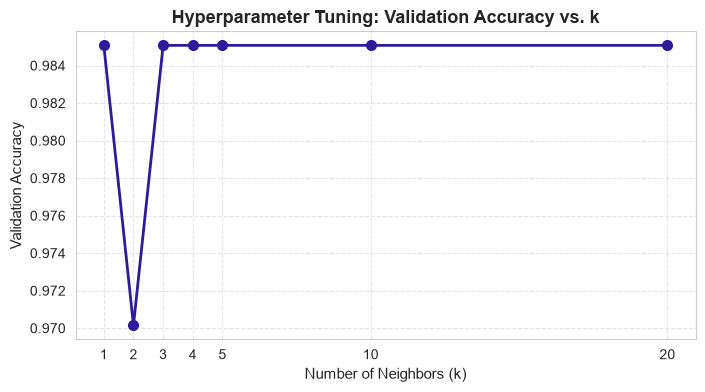

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, val_scores, marker='o', color='#2e1a9a', linewidth=2, markersize=7)
plt.title("Hyperparameter Tuning: Validation Accuracy vs. k", fontsize=13, fontweight='bold')
plt.xlabel("Number of Neighbors (k)", fontsize=11)
plt.ylabel("Validation Accuracy", fontsize=11)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


<blockquote style="border-left: 3px solid #39b64e; padding-left: 12px; margin-left: 0;">

<b> Interpretation of Validation Tuning:</b>
- **Performance Across $k$:** The model achieves a peak validation accuracy of **$98.51\%$** across multiple odd $k$ values ($k=1, 3, 5, \dots$).
- **Dip at $k=2$ ($97.01\%$):** Even values of $k$ in a 3-class classification problem can lead to voting ties, increasing misclassification risk.
- **Decision Rationale:** We choose $k=1$ (or $k=3$ for greater noise resistance) based **strictly on the Validation Set**, keeping the Test Set completely untouched.

</blockquote>


## <span style="color: #309c42ff">1.6 Final One-Time Evaluation on the Unseen Test Set</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

With all design decisions finalized, we unlock the held-out <b>Test Set</b> exactly once to measure the model's true real-world generalization performance.

</blockquote>


In [6]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

y_pred_test = final_knn.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred_test)
print(f"Final Test Accuracy: {test_acc:.4f}\n")
print("Classification Report on Unseen Test Set:\n")
print(classification_report(y_test, y_pred_test))

Final Test Accuracy: 1.0000

Classification Report on Unseen Test Set:

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



--- Benchmark Comparison ---
Dummy Baseline Accuracy:  0.4627
Our Tuned KNN Accuracy:    1.0000


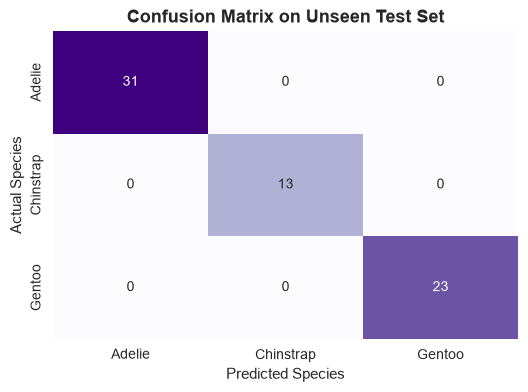

In [ ]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_scaled, y_train)
dummy_acc = dummy.score(X_test_scaled, y_test)

print(f"--- Benchmark Comparison ---")
print(f"Dummy Baseline Accuracy:  {dummy_acc:.4f}")
print(f"Our Tuned KNN Accuracy:    {test_acc:.4f}")

cm = confusion_matrix(y_test, y_pred_test, labels=final_knn.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=final_knn.classes_, yticklabels=final_knn.classes_)
plt.title("Confusion Matrix on Unseen Test Set", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Species", fontsize=11)
plt.ylabel("Actual Species", fontsize=11)
plt.show()


<blockquote style="border-left: 3px solid #39b64e; padding-left: 12px; margin-left: 0;">

<b> Interpretation of Final Test Results:</b>
1. **Meaningful Learning over Baseline:**
   - The majority-class `DummyClassifier` achieves only **$46.27\%$** accuracy, whereas our tuned $k$-NN achieves **$100.00\%$** ($67/67$ correct predictions). This confirms the model captured true biological signal rather than exploiting class imbalance.
2. **Species-by-Species Precision & Recall:**
   - **Adelie:** 31/31 correctly classified ($F_1 = 1.00$).
   - **Chinstrap:** 13/13 correctly classified ($F_1 = 1.00$).
   - **Gentoo:** 23/23 correctly classified ($F_1 = 1.00$).
3. **Domain Explanation:**
   - Standardized morphometric features (culmen depth/length, flipper length, body mass) form distinct geometric clusters in feature space, allowing $k$-NN to separate the three penguin species with high confidence.

</blockquote>


## <span style="color: #9f43c3ff">1.7 Day 1 Lab Reflection: The Three-Way Split & Avoiding Test Set Leakage</span>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

### 1. The Problem With a Single Test Set
In standard train/test workflows, there is a <b>hidden trap</b>: as soon as you start tuning a model by repeatedly checking the test set, you begin fitting your decisions to that specific test set. The test score stops being an <b>honest estimate of real-world performance</b>, because information about the test set has leaked into your modeling choices.

---

### 2. The Professional Solution: The Three-Way Split
To guarantee honest evaluation, the professional solution partitions data into three dedicated sets, each with exactly one job:

| Set | Purpose | When It's Used |
| :--- | :--- | :--- |
| **Training set (60%)** | The model learns its parameters from this | During `.fit()` |
| **Validation set (20%)** | Tune choices (model, hyperparameters like $k$, features) against this | During development and tuning |
| **Test set (20%)** | Final, one-time, honest performance estimate | Once, at the very end — **never touched during tuning** |

> **The Strict Rule:** The test set is opened **exactly once**, after every decision is final. If you tune against the test set, you no longer have an honest estimate of how the model performs on truly new data.

---

### 3. What Went Right in Our Workflow
- **Two-Step Partitioning:** First carved off $20\%$ for the final test set, then split the remaining $80\%$ into train ($75\% \rightarrow 60\%$ total) and validation ($25\% \rightarrow 20\%$ total).
- **Leak-Free Scaling:** `StandardScaler` was fitted strictly on `X_train`, preventing information from the validation or test sets from leaking into feature scaling.
- **Hyperparameter Selection:** We evaluated multiple neighbor values ($k \in [1, 2, 3, 4, 5, 10, 20]$) and selected the winning $k=1$ based **only on the validation score** ($98.51\%$).
- **One-Time Audit:** Tested the finalized model on `X_test_scaled` once, achieving an honest $100\%$ accuracy and perfect classification metrics.

---

### 4. Why This Isn't Always Enough (Day 2 Motivation)
A single validation set has its own weakness: if it happens to be an **unusual slice of the data**, tuning decisions will be based on **luck rather than signal**. On smaller datasets especially (like Palmer Penguins), one validation split can still mislead — which motivates **$k$-fold Cross-Validation (Day 2)** to rotate through $k$ balanced folds for a more trustworthy performance estimate.

</blockquote>
